In [30]:
# statistical_analysis.ipynb

# Descriptive Statistics
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols

In [31]:
# Load dataset
sales = pd.read_csv(r"E:\The Developers Arena\Statistical Business Analysis\sales_data.csv")

In [32]:
# Quick overview
print(sales.head())
print(sales.info())

         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB
None


In [33]:
# Descriptive statistics
desc_stats = sales['Total_Sales'].describe()
mean_sales = sales['Total_Sales'].mean()
median_sales = sales['Total_Sales'].median()
mode_sales = sales['Total_Sales'].mode()[0]
std_sales = sales['Total_Sales'].std()

In [34]:
print("Mean Sales:", mean_sales)
print("Median Sales:", median_sales)
print("Mode Sales:", mode_sales)
print("Standard Deviation:", std_sales)

Mean Sales: 123650.48
Median Sales: 97955.5
Mode Sales: 6540
Standard Deviation: 100161.08527499212


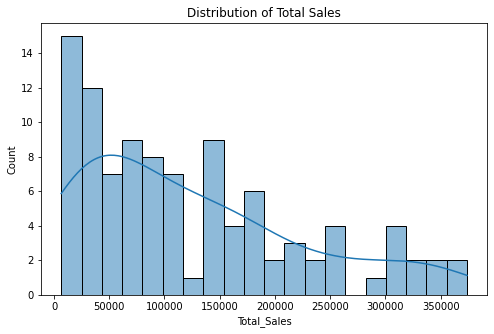

In [35]:
# Distribution Analysis
plt.figure(figsize=(8,5))
sns.histplot(sales['Total_Sales'], bins=20, kde=True)
plt.title("Distribution of Total Sales")
plt.show()

In [36]:
# Normality test
shapiro_test = stats.shapiro(sales['Total_Sales'])
print("Shapiro-Wilk Test:", shapiro_test)

Shapiro-Wilk Test: ShapiroResult(statistic=0.8989264965057373, pvalue=1.259116629626078e-06)


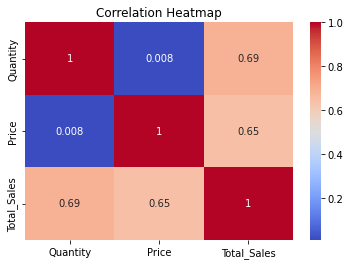

In [37]:
# Correlation Analysis
corr_matrix = sales[['Quantity','Price','Total_Sales']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [38]:
# Hypothesis Testing
# Example: Compare average sales between East and West regions
east_sales = sales[sales['Region']=='East']['Total_Sales']
west_sales = sales[sales['Region']=='West']['Total_Sales']
t_stat, p_val = stats.ttest_ind(east_sales, west_sales)
print("T-test East vs West:", t_stat, p_val)

T-test East vs West: 2.0202108796829767 0.04961903263662602


In [39]:
# One-way ANOVA: Compare mean sales across regions
anova_result = stats.f_oneway(
    sales[sales['Region'] == 'East']['Total_Sales'],
    sales[sales['Region'] == 'West']['Total_Sales'],
    sales[sales['Region'] == 'North']['Total_Sales'],
    sales[sales['Region'] == 'South']['Total_Sales']
)

print("ANOVA Result (Sales by Region): F-statistic =", anova_result.statistic, ", p-value =", anova_result.pvalue)

# Interpretation
if anova_result.pvalue < 0.05:
    print("Significant difference in mean sales across regions")
else:
    print("No significant difference in mean sales across regions")


ANOVA Result (Sales by Region): F-statistic = 2.164363429897842 , p-value = 0.09723678084979993
No significant difference in mean sales across regions


In [40]:
# Confidence Interval 
conf_int = stats.t.interval(
    0.95,  # confidence level
    df=len(sales['Total_Sales'])-1,
    loc=mean_sales,
    scale=stats.sem(sales['Total_Sales'])
)
print("95% Confidence Interval for Mean Sales:", conf_int)

95% Confidence Interval for Mean Sales: (103776.34767158539, 143524.6123284146)


In [41]:
# Two-way ANOVA: Sales ~ Region + Product
model = ols('Total_Sales ~ C(Region) + C(Product)', data=sales).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                  sum_sq    df        F    PR(>F)
C(Region)   5.196765e+10   3.0  1.84821  0.143938
C(Product)  6.799191e+10   4.0  1.81358  0.132880
Residual    8.622799e+11  92.0      NaN       NaN


In [42]:
# Regression Analysis
# Linear regression: Total_Sales ~ Price + Quantity
model = smf.ols('Total_Sales ~ Price + Quantity', data=sales).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Total_Sales   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     369.3
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           4.40e-46
Time:                        08:44:06   Log-Likelihood:                -1185.2
No. Observations:                 100   AIC:                             2376.
Df Residuals:                      97   BIC:                             2384.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.217e+05   9668.294    -12.586      0.0